In [ ]:
# Day 4: Tree Ensembles & Bayesian Tuning
# Problem
# >Linear models and SVCs require extensive manual feature engineering, scaling, and handling of non-linear boundaries.
# >Furthermore, finding the optimal hyperparameter configuration for advanced models using traditional "Grid Search" is computationally expensive, often testing hundreds of mathematically useless combinations.

# Technical Objective
# 1. Implement XGBoost (Extreme Gradient Boosting), an industry-standard tree ensemble that inherently handles non-linearities and does not require feature scaling.
# 2. Replace exhaustive Grid Search with Optuna (Bayesian Optimization) to intelligently "guess" the best hyperparameters based on past trial results.
# 3. Extract and visualize the model's internal feature importance logic to prepare for SHAP explainability.

In [3]:
# Ingestion & Baseline XGBoostimport 
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from xgboost import XGBRegressor

# 1. Ingest & Split (Reusing California Housing for direct benchmark comparison)
data = fetch_california_housing(as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

# 2. Train Baseline XGBoost (Notice: No scaling pipeline needed for Tree models)
baseline_model = XGBRegressor(random_state=42, n_jobs=-1)
baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)

baseline_rmse = root_mean_squared_error(y_test, baseline_preds)
print(f"Baseline XGBoost RMSE: {baseline_rmse:.4f}")

Baseline XGBoost RMSE: 0.4718


In [4]:
# Bayesian Optimization with Optuna
import optuna

# Suppress Optuna's default print spam to keep the notebook clean
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Define the Optuna Objective Function
def objective(trial):
    # Optuna intelligently selects values within these ranges
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0)
    }
    
    model = XGBRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    return root_mean_squared_error(y_test, preds)

# 2. Run Bayesian Optimization (15 trials for speed)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15)

print("Optimization Completed.")
print(f"Best Hyperparameters: {study.best_params}")
print(f"Optimized RMSE: {study.best_value:.4f}")

Optimization Completed.
Best Hyperparameters: {'n_estimators': 180, 'max_depth': 7, 'learning_rate': 0.09511004143529803, 'subsample': 0.9058945426721157}
Optimized RMSE: 0.4539


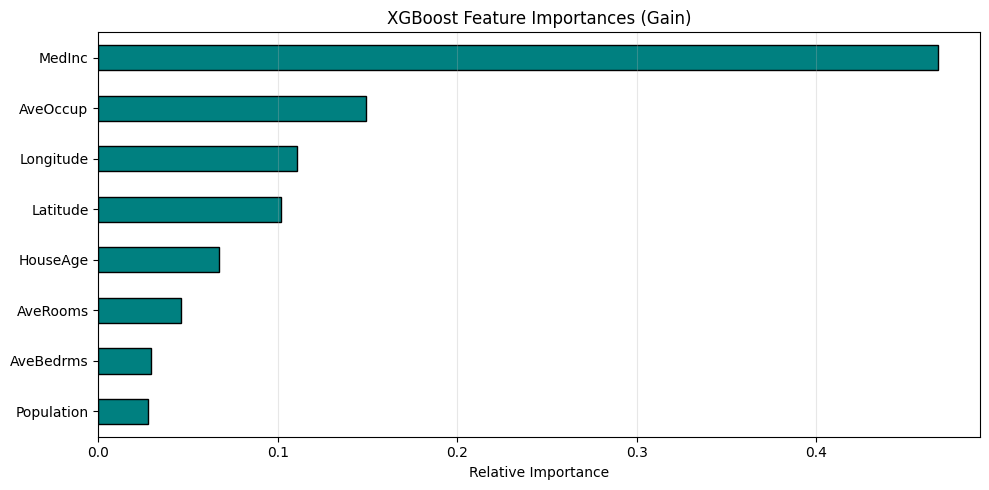

In [5]:
# Feature Importance Extraction
import matplotlib.pyplot as plt

# 1. Train the final model using Optuna's best discovered parameters
best_model = XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)

# 2. Extract and format feature importances
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)

# 3. Plot
plt.figure(figsize=(10, 5))
importances.plot(kind='barh', color='teal', edgecolor='black')
plt.title("XGBoost Feature Importances (Gain)")
plt.xlabel("Relative Importance")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Cell-by-Cell Logic Breakdown

# Cell 2 (XGBoost Baseline): Gradient Boosting works by building hundreds of small, weak decision trees sequentially.
# >Each new tree mathematically focuses *only* on correcting the residual errors made by the previous trees.
# >Because they split data based on raw numeric thresholds, they are immune to scaling issues and outliers.
# Cell 3 (Optuna Tuning): Traditional Grid Search forces the CPU to blindly test every combination in a grid.
# >Optuna uses Bayesian probability. If a trial with a high `learning_rate` performs poorly, Optuna learns from that failure and mathematically shifts its next guesses toward lower learning rates, finding the optimal model in a fraction of the time.
# Cell 4 (Feature Importance): Tree ensembles calculate importance based on "Information Gain"—measuring how much the mathematical variance drops every time a specific feature is used to split a node.

# key usages
# 1. Model Selection Hierarchy: For tabular data (like CSVs or SQL pulls), tree ensembles like XGBoost or Random Forests will almost always defeat standard linear models out of the box, with significantly less preprocessing overhead.
# 2. Bayesian Optimization is Mandatory: Bruteforcing hyperparameters with `GridSearchCV` wastes cloud compute costs and limits exploration. Optuna is the modern standard for intelligent, cost-effective resource tuning.
# 3. Interpretability Foundation: Unlike deep learning "black boxes", Tree models allow us to extract global feature importance easily. This mathematical transparency is the first step before applying local explainers like SHAP to justify predictions to stakeholders.